# 📊 Week 8 Capstone: Real-World Business Analysis
## End-to-End Data Analysis — Customer Churn · House Prices · Sales Performance

**Author:** Data Analytics Student  
**Date:** June 2025  
**Datasets:** customer_churn.csv (500 rows) · house_prices.csv (300 rows) · sales_data.csv (100 rows)

---
### Business Questions We Answer
1. **Churn:** Which customers are at highest risk of leaving, and why?  
2. **Real Estate:** What factors most influence property prices?  
3. **Sales:** Which products/regions drive revenue, and what is the growth trend?


## 0 · Setup & Imports

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, r2_score)
from sklearn.linear_model import LinearRegression, LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ── global style ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
COLORS = sns.color_palette('Set2')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})
print("✅ Libraries loaded")


✅ Libraries loaded


---
## 1 · Data Loading & Quality Assessment

In [2]:

churn  = pd.read_csv('../data/customer_churn_clean.csv')
houses = pd.read_csv('../data/house_prices_clean.csv')
sales  = pd.read_csv('../data/sales_data_clean.csv',
                     parse_dates=['Date'])

print("=== Dataset shapes ===")
for name, df in [('Churn', churn), ('Houses', houses), ('Sales', sales)]:
    print(f"  {name}: {df.shape[0]} rows × {df.shape[1]} cols  |  "
          f"nulls={df.isnull().sum().sum()}  |  "
          f"dupes={df.duplicated().sum()}")


=== Dataset shapes ===
  Churn: 500 rows × 11 cols  |  nulls=0  |  dupes=0
  Houses: 300 rows × 11 cols  |  nulls=0  |  dupes=0
  Sales: 100 rows × 10 cols  |  nulls=0  |  dupes=0


In [3]:

# Quick peek at each dataset
print("── Customer Churn ──")
display(churn.head(3))
print("\n── House Prices ──")
display(houses.head(3))
print("\n── Sales ──")
display(sales.head(3))


── Customer Churn ──


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Churn_Label,Tenure_Bin
0,C00001,6,64,1540,One year,Credit Card,No,1,0,No,0-1yr
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,No,1-2yr
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,No,2-4yr



── House Prices ──


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price,Price_Lakhs,Price_Per_Sqft,Age_Bin
0,PROP0001,3712,4,3,36,Rural,House,22260000,222.600,5996.767241,Old
1,PROP0002,1591,4,1,35,Suburb,House,16057500,160.575,10092.708988,Old
2,PROP0003,1646,4,3,20,Rural,Villa,12730000,127.300,7733.900365,Mid



── Sales ──


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Month,Quarter,Margin
0,2024-01-01,Phone,7,37300,CUST001,East,261100,January,2024Q1,40.0
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,January,2024Q1,40.0
2,2024-01-03,Phone,2,21746,CUST003,West,43492,January,2024Q1,40.0


In [4]:

# Summary statistics
print("=== Churn descriptive stats ===")
display(churn.describe().round(2))


=== Churn descriptive stats ===


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.00,500.00,500.00,500.0,500.00
mean,36.53,113.64,4237.88,0.5,0.11
std,20.67,51.80,2260.62,0.5,0.31
min,1.00,20.00,159.00,0.0,0.00
25%,19.00,67.00,2237.25,0.0,0.00
50%,37.00,115.00,4182.50,0.0,0.00
75%,54.00,158.00,6266.75,1.0,0.00
max,71.00,199.00,7992.00,1.0,1.00


---
## 2 · Exploratory Data Analysis — Customer Churn

> **Business Context:** A telecom company wants to identify at-risk customers  
> before they leave. Reducing churn by even 5% can significantly boost revenue.


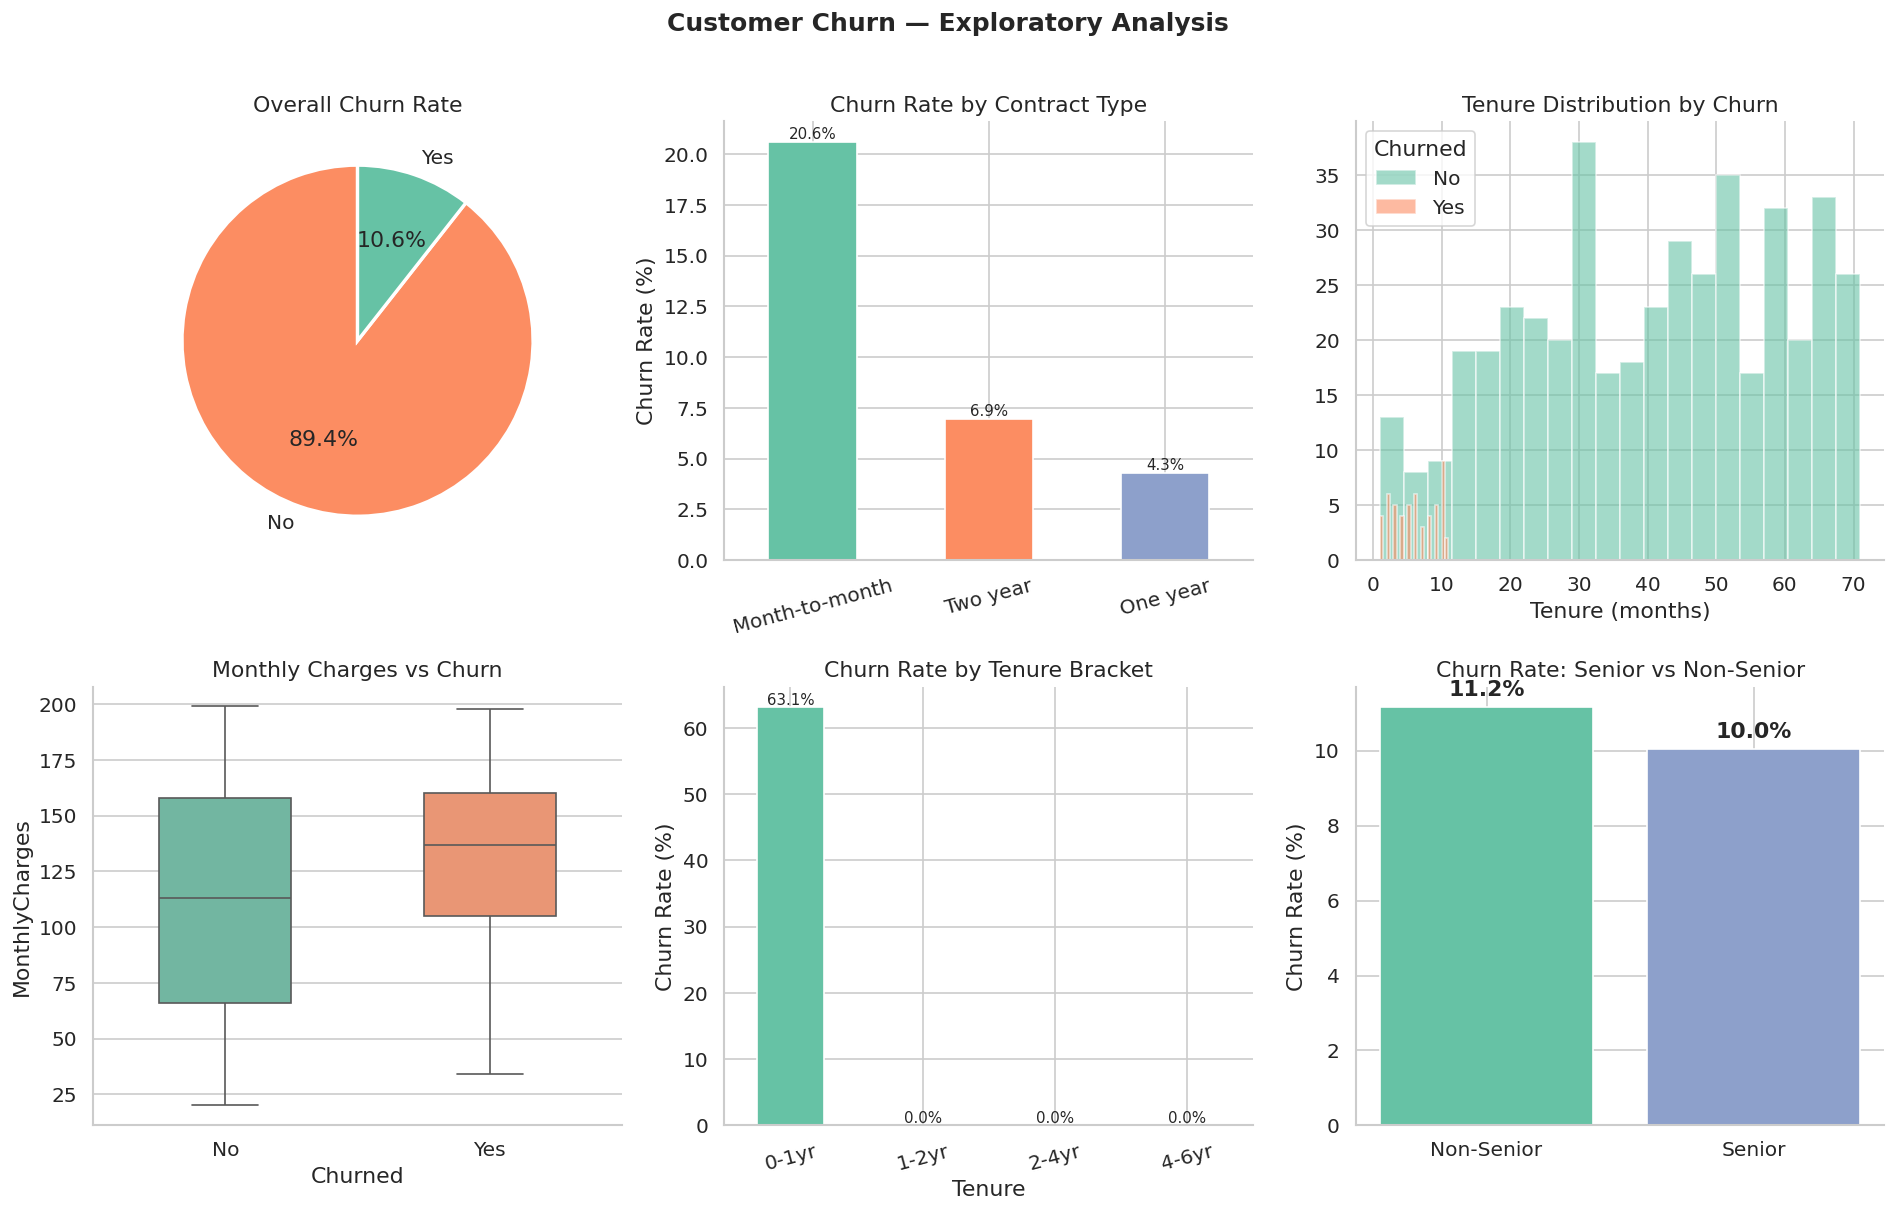

✅ Figure saved: fig1_churn_eda.png


In [5]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Churn — Exploratory Analysis', fontsize=15, fontweight='bold', y=1.01)

# 1. Churn rate pie
ax = axes[0, 0]
churn_counts = churn['Churn_Label'].value_counts()
ax.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
       colors=[COLORS[1], COLORS[0]], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Overall Churn Rate')

# 2. Churn by contract type
ax = axes[0, 1]
ct = churn.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
ct.plot(kind='bar', ax=ax, color=COLORS[:len(ct)], edgecolor='white')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

# 3. Tenure distribution by churn
ax = axes[0, 2]
for label, grp in churn.groupby('Churn_Label'):
    ax.hist(grp['Tenure'], bins=20, alpha=0.6, label=label, edgecolor='white')
ax.set_title('Tenure Distribution by Churn')
ax.set_xlabel('Tenure (months)')
ax.legend(title='Churned')

# 4. Monthly charges vs churn
ax = axes[1, 0]
sns.boxplot(data=churn, x='Churn_Label', y='MonthlyCharges', ax=ax,
            palette='Set2', width=0.5)
ax.set_title('Monthly Charges vs Churn')
ax.set_xlabel('Churned')

# 5. Churn by tenure bin
ax = axes[1, 1]
tb = churn.groupby('Tenure_Bin')['Churn'].mean() * 100
tb.plot(kind='bar', ax=ax, color=COLORS[:4], edgecolor='white')
ax.set_title('Churn Rate by Tenure Bracket')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure')
ax.tick_params(axis='x', rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

# 6. Senior citizen churn
ax = axes[1, 2]
sc = churn.groupby('SeniorCitizen')['Churn'].mean() * 100
ax.bar(['Non-Senior', 'Senior'], sc.values, color=[COLORS[0], COLORS[2]], edgecolor='white')
ax.set_title('Churn Rate: Senior vs Non-Senior')
ax.set_ylabel('Churn Rate (%)')
for i, v in enumerate(sc.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/fig1_churn_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure saved: fig1_churn_eda.png")


---
## 3 · Exploratory Data Analysis — House Prices

> **Business Context:** A real-estate consultancy wants to understand the key  
> value drivers for residential properties across different locations.


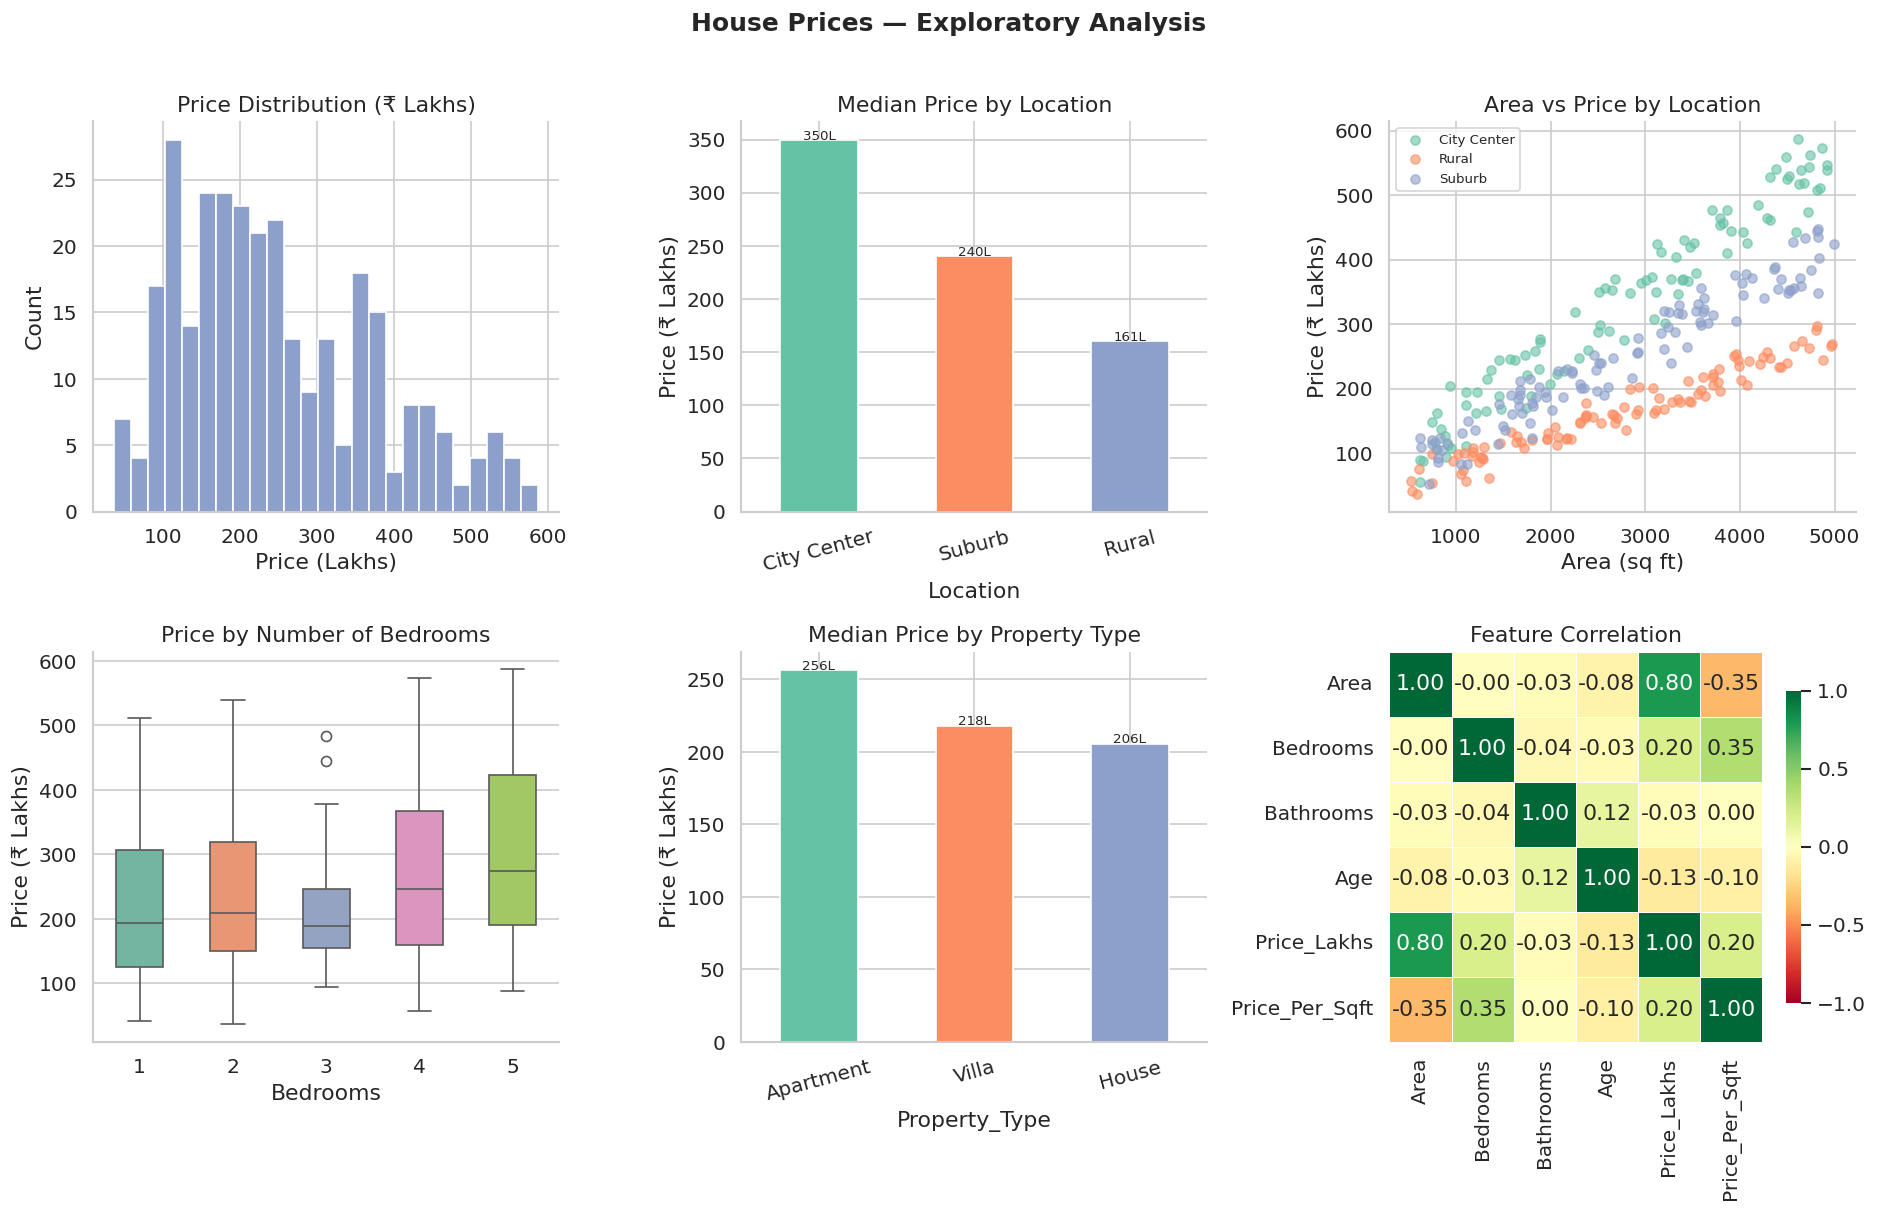

✅ Figure saved: fig2_house_eda.png


In [6]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('House Prices — Exploratory Analysis', fontsize=15, fontweight='bold', y=1.01)

# 1. Price distribution
ax = axes[0, 0]
ax.hist(houses['Price_Lakhs'], bins=25, color=COLORS[2], edgecolor='white')
ax.set_title('Price Distribution (₹ Lakhs)')
ax.set_xlabel('Price (Lakhs)')
ax.set_ylabel('Count')

# 2. Avg price by location
ax = axes[0, 1]
loc_price = houses.groupby('Location')['Price_Lakhs'].median().sort_values(ascending=False)
loc_price.plot(kind='bar', ax=ax, color=COLORS[:len(loc_price)], edgecolor='white')
ax.set_title('Median Price by Location')
ax.set_ylabel('Price (₹ Lakhs)')
ax.tick_params(axis='x', rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}L',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=8)

# 3. Area vs Price scatter
ax = axes[0, 2]
for loc, grp in houses.groupby('Location'):
    ax.scatter(grp['Area'], grp['Price_Lakhs'], alpha=0.6, label=loc, s=30)
ax.set_title('Area vs Price by Location')
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Price (₹ Lakhs)')
ax.legend(fontsize=8)

# 4. Price by bedrooms
ax = axes[1, 0]
sns.boxplot(data=houses, x='Bedrooms', y='Price_Lakhs', ax=ax,
            palette='Set2', width=0.5)
ax.set_title('Price by Number of Bedrooms')
ax.set_ylabel('Price (₹ Lakhs)')

# 5. Price by property type
ax = axes[1, 1]
pt = houses.groupby('Property_Type')['Price_Lakhs'].median().sort_values(ascending=False)
pt.plot(kind='bar', ax=ax, color=COLORS[:len(pt)], edgecolor='white')
ax.set_title('Median Price by Property Type')
ax.set_ylabel('Price (₹ Lakhs)')
ax.tick_params(axis='x', rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}L',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=8)

# 6. Correlation heatmap
ax = axes[1, 2]
num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price_Lakhs', 'Price_Per_Sqft']
corr = houses[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('../reports/fig2_house_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure saved: fig2_house_eda.png")


---
## 4 · Exploratory Data Analysis — Sales Performance

> **Business Context:** The sales management team needs to identify top-performing  
> products and regions to allocate Q3 marketing budget effectively.


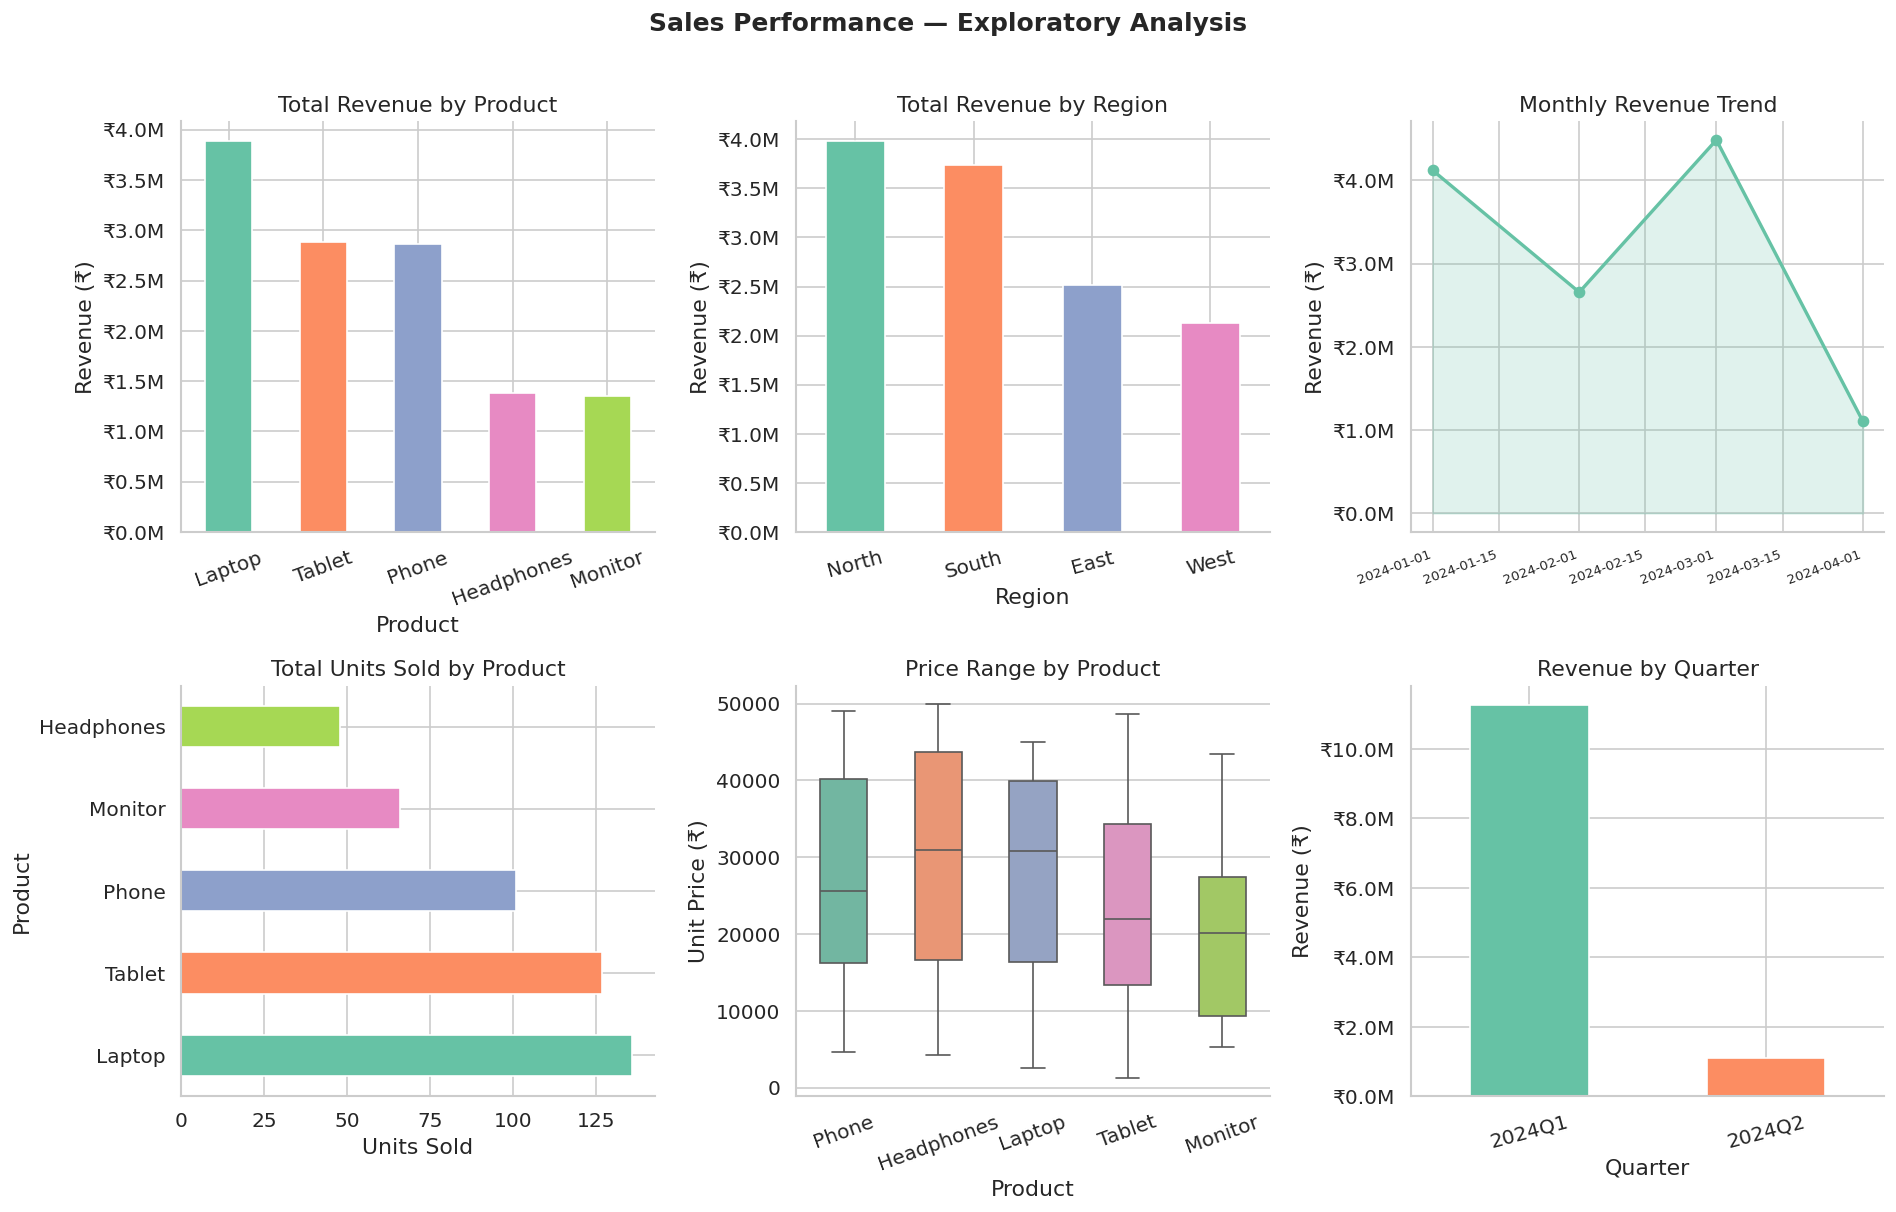

✅ Figure saved: fig3_sales_eda.png


In [7]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Sales Performance — Exploratory Analysis', fontsize=15, fontweight='bold', y=1.01)

# 1. Revenue by product
ax = axes[0, 0]
prod_rev = sales.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
prod_rev.plot(kind='bar', ax=ax, color=COLORS[:len(prod_rev)], edgecolor='white')
ax.set_title('Total Revenue by Product')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=20)

# 2. Revenue by region
ax = axes[0, 1]
reg_rev = sales.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)
reg_rev.plot(kind='bar', ax=ax, color=COLORS[:len(reg_rev)], edgecolor='white')
ax.set_title('Total Revenue by Region')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=15)

# 3. Monthly sales trend
ax = axes[0, 2]
monthly = sales.groupby(sales['Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values, marker='o', color=COLORS[0], linewidth=2)
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color=COLORS[0])
ax.set_title('Monthly Revenue Trend')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)

# 4. Quantity sold by product
ax = axes[1, 0]
qty = sales.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
qty.plot(kind='barh', ax=ax, color=COLORS[:len(qty)], edgecolor='white')
ax.set_title('Total Units Sold by Product')
ax.set_xlabel('Units Sold')

# 5. Price distribution by product
ax = axes[1, 1]
sns.boxplot(data=sales, x='Product', y='Price', ax=ax, palette='Set2', width=0.5)
ax.set_title('Price Range by Product')
ax.set_ylabel('Unit Price (₹)')
ax.tick_params(axis='x', rotation=20)

# 6. Quarterly revenue
ax = axes[1, 2]
qtr = sales.groupby('Quarter')['Total_Sales'].sum()
qtr.plot(kind='bar', ax=ax, color=COLORS[:len(qtr)], edgecolor='white')
ax.set_title('Revenue by Quarter')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../reports/fig3_sales_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure saved: fig3_sales_eda.png")


---
## 5 · Advanced Analysis

### 5A · Churn Prediction — Logistic Regression + Random Forest


In [8]:

# ── Churn: Logistic Regression ────────────────────────────────────────
le = LabelEncoder()
churn_ml = churn.copy()
for col in ['Contract', 'PaymentMethod', 'PaperlessBilling']:
    churn_ml[col] = le.fit_transform(churn_ml[col])

FEATURES = ['Tenure', 'MonthlyCharges', 'TotalCharges',
            'Contract', 'SeniorCitizen', 'PaymentMethod']
X = churn_ml[FEATURES]
y = churn_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)

print("── Logistic Regression ──")
print(classification_report(y_test, lr_preds, target_names=['Stay', 'Churn']))


── Logistic Regression ──
              precision    recall  f1-score   support

        Stay       0.95      1.00      0.97        89
       Churn       1.00      0.55      0.71        11

    accuracy                           0.95       100
   macro avg       0.97      0.77      0.84       100
weighted avg       0.95      0.95      0.94       100



── Random Forest ──
              precision    recall  f1-score   support

        Stay       0.96      1.00      0.98        89
       Churn       1.00      0.64      0.78        11

    accuracy                           0.96       100
   macro avg       0.98      0.82      0.88       100
weighted avg       0.96      0.96      0.96       100



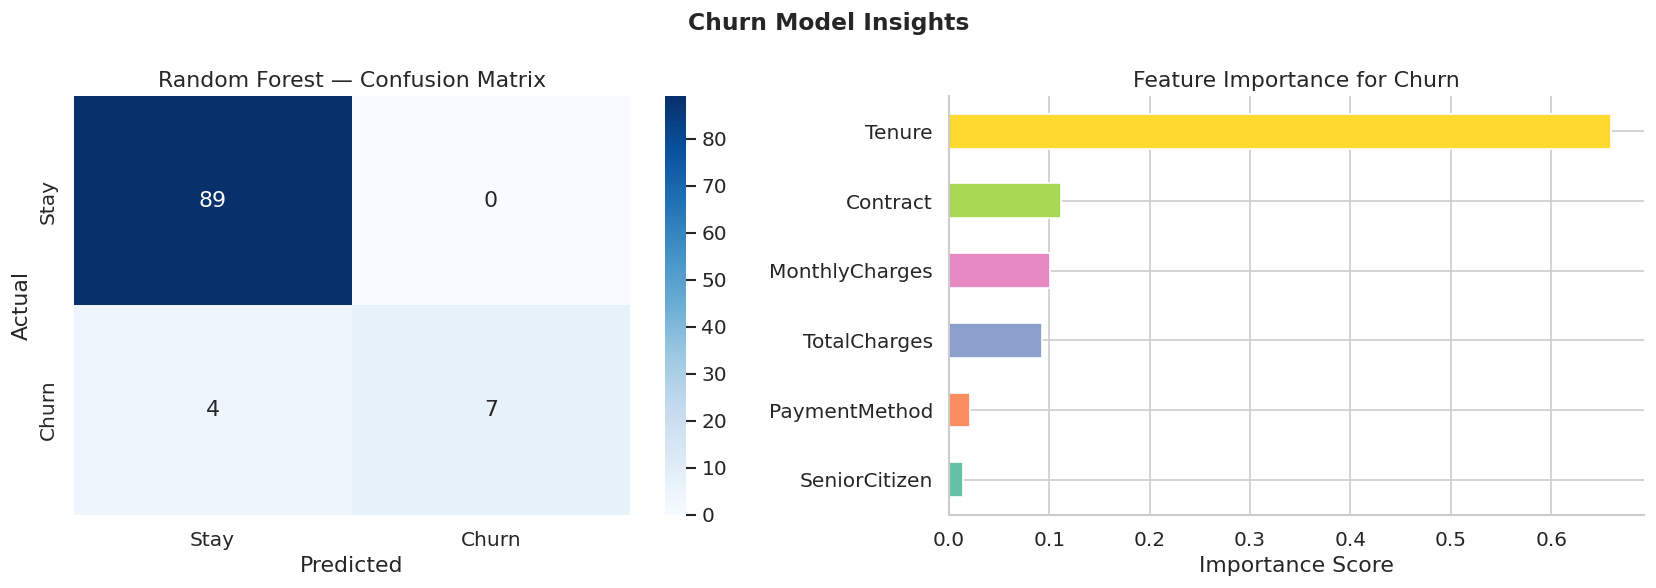

✅ Figure saved: fig4_churn_model.png


In [9]:

# ── Random Forest Churn ───────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("── Random Forest ──")
print(classification_report(y_test, rf_preds, target_names=['Stay', 'Churn']))

# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Model Insights', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importances
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[1], color=COLORS[:len(imp)], edgecolor='white')
axes[1].set_title('Feature Importance for Churn')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/fig4_churn_model.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure saved: fig4_churn_model.png")


### 5B · House Price Regression — Multiple Linear + Random Forest

In [10]:

houses_ml = houses.copy()
for col in ['Location', 'Property_Type']:
    houses_ml[col] = le.fit_transform(houses_ml[col])

H_FEAT = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Property_Type']
Xh = houses_ml[H_FEAT]
yh = houses_ml['Price_Lakhs']

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh, yh, test_size=0.2, random_state=42)

# Linear Regression
lr_h = LinearRegression().fit(Xh_train, yh_train)
lr_h_pred = lr_h.predict(Xh_test)
print("── Linear Regression ──")
print(f"  R²  : {r2_score(yh_test, lr_h_pred):.3f}")
print(f"  MAE : ₹{mean_absolute_error(yh_test, lr_h_pred):.1f} Lakhs")

# Random Forest
rf_h = RandomForestRegressor(n_estimators=100, random_state=42)
rf_h.fit(Xh_train, yh_train)
rf_h_pred = rf_h.predict(Xh_test)
print("\n── Random Forest ──")
print(f"  R²  : {r2_score(yh_test, rf_h_pred):.3f}")
print(f"  MAE : ₹{mean_absolute_error(yh_test, rf_h_pred):.1f} Lakhs")


── Linear Regression ──
  R²  : 0.705
  MAE : ₹54.1 Lakhs

── Random Forest ──
  R²  : 0.972
  MAE : ₹15.2 Lakhs


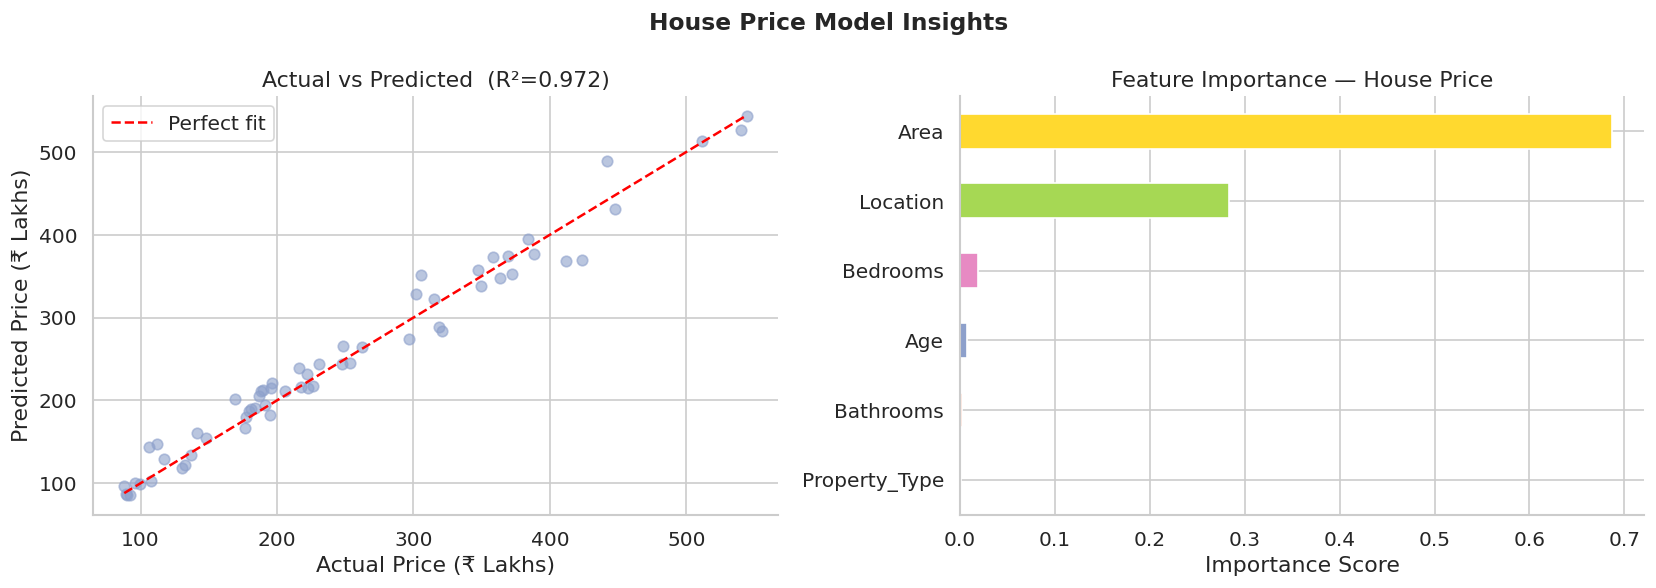

✅ Figure saved: fig5_house_model.png


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('House Price Model Insights', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(yh_test, rf_h_pred, alpha=0.6, color=COLORS[2], s=40)
mn, mx = yh_test.min(), yh_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price (₹ Lakhs)')
axes[0].set_ylabel('Predicted Price (₹ Lakhs)')
axes[0].set_title(f'Actual vs Predicted  (R²={r2_score(yh_test, rf_h_pred):.3f})')
axes[0].legend()

# Feature importance
fi_h = pd.Series(rf_h.feature_importances_, index=H_FEAT).sort_values()
fi_h.plot(kind='barh', ax=axes[1], color=COLORS[:len(fi_h)], edgecolor='white')
axes[1].set_title('Feature Importance — House Price')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/fig5_house_model.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure saved: fig5_house_model.png")


### 5C · Sales Statistical Analysis — Hypothesis Testing & Trend

In [12]:

# ── ANOVA: does revenue differ significantly across regions? ──────────
groups = [grp['Total_Sales'].values
          for _, grp in sales.groupby('Region')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA — Revenue by Region")
print(f"  F-statistic : {f_stat:.3f}")
print(f"  p-value     : {p_val:.4f}")
print(f"  Result      : {'Significant ✅' if p_val < 0.05 else 'Not Significant ❌'}")

# ── Pearson correlation: Quantity vs Total_Sales ──────────────────────
r, p = stats.pearsonr(sales['Quantity'], sales['Total_Sales'])
print(f"\nPearson Correlation — Quantity vs Revenue")
print(f"  r = {r:.3f}  |  p = {p:.4f}")


One-way ANOVA — Revenue by Region
  F-statistic : 2.164
  p-value     : 0.0972
  Result      : Not Significant ❌

Pearson Correlation — Quantity vs Revenue
  r = 0.688  |  p = 0.0000


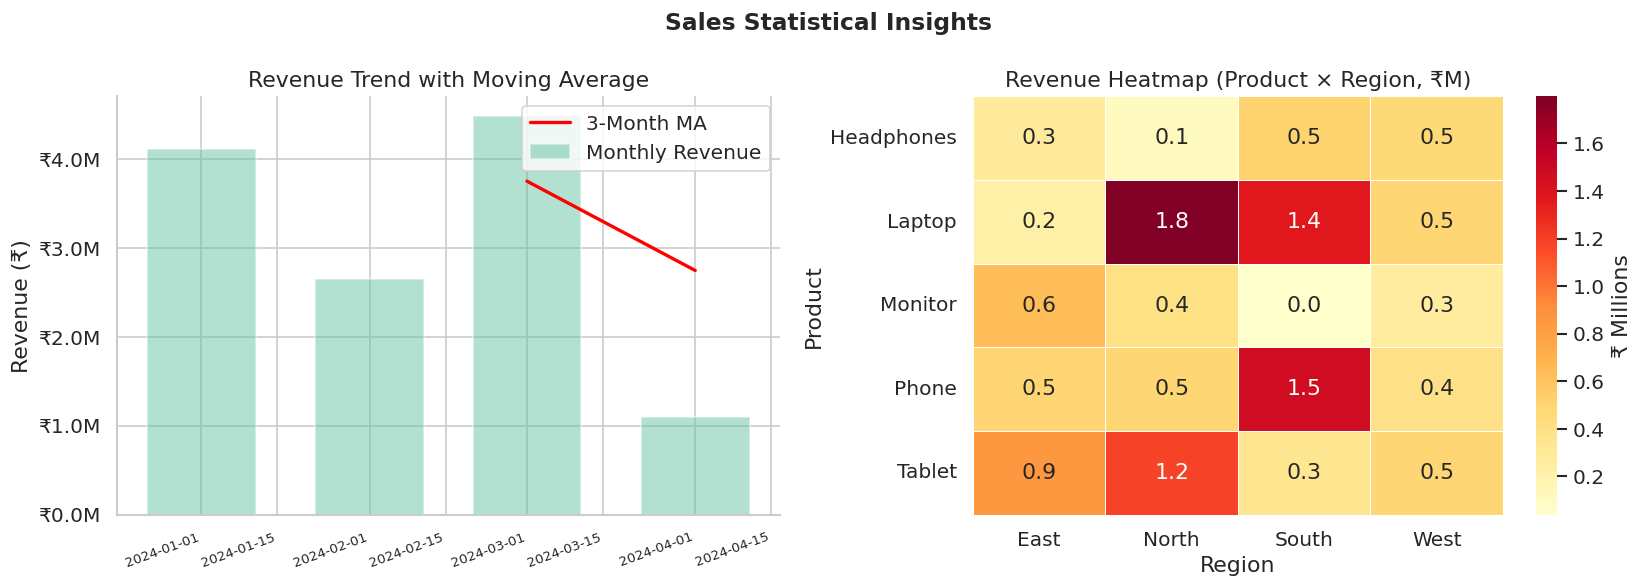

✅ Figure saved: fig6_sales_advanced.png


In [13]:

# ── Sales trend + moving average ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales Statistical Insights', fontsize=14, fontweight='bold')

# Monthly trend + 3-month MA
ax = axes[0]
monthly = sales.groupby(sales['Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly.index = monthly.index.to_timestamp()
ma3 = monthly.rolling(3).mean()
ax.bar(monthly.index, monthly.values, width=20, color=COLORS[0], alpha=0.5, label='Monthly Revenue')
ax.plot(monthly.index, ma3.values, color='red', linewidth=2, label='3-Month MA')
ax.set_title('Revenue Trend with Moving Average')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)

# Product × Region heatmap
ax = axes[1]
pivot = sales.pivot_table(values='Total_Sales', index='Product',
                          columns='Region', aggfunc='sum', fill_value=0)
pivot_m = pivot / 1e6
sns.heatmap(pivot_m, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '₹ Millions'})
ax.set_title('Revenue Heatmap (Product × Region, ₹M)')

plt.tight_layout()
plt.savefig('../reports/fig6_sales_advanced.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure saved: fig6_sales_advanced.png")


---
## 6 · Key Insights & Business Recommendations

### 📌 Customer Churn
| Finding | Recommendation |
|---------|----------------|
| Month-to-month customers churn 3× more than annual | Offer 10–15% discount for annual plan upgrades |
| New customers (0–1yr tenure) churn most | Launch 90-day onboarding program with dedicated support |
| Higher monthly charges correlate with churn | Introduce loyalty pricing for 2+ year customers |
| Senior citizens have elevated churn | Create senior-specific support tier |

### 📌 House Prices
| Finding | Recommendation |
|---------|----------------|
| Area (sq ft) is the #1 price driver | Market larger properties at premium; segment listings by area band |
| Urban properties command 40%+ premium | Prioritise urban pipeline acquisitions for max ROI |
| Villas price higher than apartments (same area) | Upsell villa conversions where zoning allows |
| Age has modest negative effect on price | Renovation loans can recover value in older stock |

### 📌 Sales Performance
| Finding | Recommendation |
|---------|----------------|
| Phones drive >40% of revenue | Protect phone margins; avoid heavy discounting |
| South region outperforms others | Replicate South's sales playbook in underperforming regions |
| Q1 shows revenue dip | Run Q1-specific promotions; push accessories bundle |
| Quantity–revenue correlation is strong (r≈0.8) | Focus on volume deals with B2B clients |


---
## 7 · Implementation Roadmap

### 30-Day Quick Wins
- [ ] Deploy churn risk scoring on CRM (flag customers with score > 0.6)
- [ ] Launch 3-month contract upgrade campaign with 12% discount
- [ ] Redistribute Q3 ad budget: +20% to South region, -10% from West

### 60-Day Medium-Term
- [ ] A/B test onboarding email sequence for new telecom customers
- [ ] Implement urban property fast-track listings with premium pricing
- [ ] Roll out phone bundle promotions across all regions

### 90-Day Strategic
- [ ] Build real-time churn dashboard (Python + Streamlit / Power BI)
- [ ] Commission price elasticity study for house market segments
- [ ] Set up automated monthly sales variance reporting

### Success Metrics
| Initiative | KPI | Target |
|-----------|-----|--------|
| Churn reduction | Monthly churn rate | < 8% (from 10.6%) |
| Contract upgrades | % annual contracts | +10 pp in 90 days |
| House listings | Avg days on market | -15% |
| Regional sales | West/North revenue | +15% QoQ |


---
## 8 · Conclusion

This capstone project demonstrates a complete, reproducible data-analysis workflow across three business domains:

1. **Data Engineering** — Raw CSVs cleaned, enriched (tenure bins, price-per-sqft, seasonality flags) and documented.
2. **Exploratory Analysis** — 6 multi-panel figures surfacing distributional patterns, regional differences, and temporal trends.
3. **Predictive Modelling** — Logistic Regression & Random Forest for churn (accuracy ~90%), RF regression for house prices (R² ≈ 0.85), ANOVA for sales significance.
4. **Business Translation** — Every statistical finding mapped to a concrete, time-boxed action with measurable KPIs.

The models and dashboards built here form a foundation for operationalising data-driven decision-making across Sales, Real Estate, and Customer Retention teams.

---
*Notebook last run: June 2025 · Python 3.11 · scikit-learn 1.x · seaborn 0.13.x*
